# Topic Modeling Pipeline
## FYE Town Hall Meeting Survey Analysis

**Author:** Student Researcher  
**Project:** First Year Experience Research and Engagement  
**Institution:** California State University, Chico  
**Date:** April 2026

---

## Notebook Overview

This notebook applies Latent Dirichlet Allocation (LDA) topic modeling to discover latent themes in THM survey responses.

### Objectives:
1. Load preprocessed token data from Google Drive
2. Build document-term matrix using CountVectorizer
3. Auto-tune number of topics (k=3→15) using perplexity and log-likelihood
4. Train final LDA model with optimal k
5. Extract topic keywords and document-topic distributions
6. Analyze topic prevalence trends by semester
7. Generate visualizations and save outputs to Google Drive

### Implementation Note:
This notebook uses **scikit-learn's LDA** implementation rather than gensim, as gensim requires C++ compilation on Windows. Scikit-learn provides equivalent functionality with pure Python.

---
## 1. Environment Setup

In [3]:
import sys
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-learn for topic modeling
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import LatentDirichletAllocation

from tqdm.auto import tqdm

# Project imports
sys.path.append('..')
from utils.gdrive_auth import DriveDataLoader
from config import PREPROCESSED_DATA_FOLDER_ID, MAIN_FOLDER_ID, GDRIVE_FILES

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✓ Imports successful")

✓ Imports successful


---
## 2. Load Preprocessed Data from Google Drive

In [4]:
print("Initializing Google Drive connection...")
loader = DriveDataLoader()

# Run access check
all_ok = loader.run_full_check(
    main_folder_id   = MAIN_FOLDER_ID,
    output_folder_id = PREPROCESSED_DATA_FOLDER_ID,
    gdrive_files = GDRIVE_FILES
)

if not all_ok:
    raise SystemExit('\n⛔ Access check failed. Fix the issues above before proceeding.')

Initializing Google Drive connection...

  FYE PROJECT — GOOGLE DRIVE ACCESS CHECK

GOOGLE DRIVE AUTHENTICATION

🔐 You will be prompted to log in with your Google account
📋 Make sure you have access to the THM_Survey_Data folder

Steps:
  1. Browser will open
  2. Select your Google account
  3. Click 'Allow' to grant access
  4. Return here to continue


→ Using saved credentials...

✓ AUTHENTICATED AS: hvhasabnis@csuchico.edu

✓ Ready to load data from Google Drive

  🔍 Checking READ access... ✅  (2 files visible)
  🔍 Checking WRITE access... ✅

  🔍 Verifying all dataset files...
    ✅  text_prepared        — THM_All_Semesters_TEXT_PREPARED (315 KB)
    ✅  quant_prepared       — THM_All_Semesters_QUANTITATIVE_PREPARED (17 KB)
    ✅  fall_2022            — THM_Fall_2022 (60 KB)
    ✅  spring_2023          — THM_Spring_2023 (63 KB)
    ✅  fall_2023            — THM_Fall_2023 (33 KB)
    ✅  spring_2024          — THM_Spring_2024 (23 KB)
    ✅  fall_2024            — THM_Fall_2024 (61 KB

In [5]:
print("Loading preprocessed tokens from Drive...")

# Find the preprocessed_tokens.csv file
file_list = loader.drive.ListFile({
    'q': f"'{PREPROCESSED_DATA_FOLDER_ID}' in parents and trashed=false and title='preprocessed_tokens.csv'"
}).GetList()

if not file_list:
    raise FileNotFoundError("preprocessed_tokens.csv not found in Drive. Run 02_text_preprocessing first.")

file_id = file_list[0]['id']
df = loader.read_csv(file_id, label='preprocessed_tokens')

print(f"\nDataset loaded successfully!")
print(f"  Total documents: {len(df):,}")
print(f"  Columns: {list(df.columns)}")
print(f"  Semesters: {df['Semester'].nunique()}")

Loading preprocessed tokens from Drive...
  [preprocessed_tokens] Loading CSV (ID: 1vMIOAImKlQFRjm8yaOq...)... ✓ (3585, 4)

Dataset loaded successfully!
  Total documents: 3,585
  Columns: ['Semester', 'Question_Category', 'tokens', 'tokens_text']
  Semesters: 7


In [6]:
# Preview data
print("\nSample documents:")
for idx, row in df.sample(3, random_state=42).iterrows():
    tokens = row['tokens_text'][:100] if isinstance(row['tokens_text'], str) else str(row['tokens_text'])[:100]
    print(f"  [{row['Semester']}] {tokens}...")


Sample documents:
  [Fall_2025] fall2025116 fall academic ability response question help accurately describe increase confidence stu...
  [Fall_2025] fall202580 fall academic ability response question help accurately describe increase confidence stud...
  [Spring_2023] spring2023254 spring town hall meeting mean town hall meeting mean got motivation understood importa...


---
## 3. Build Document-Term Matrix

In [7]:
# Prepare text data
print("Preparing documents...")

# Filter out empty documents
df = df[df['tokens_text'].notna() & (df['tokens_text'].str.strip() != '')].copy()
documents = df['tokens_text'].tolist()

print(f"  Documents with content: {len(documents):,}")

Preparing documents...
  Documents with content: 3,585


In [8]:
# Create CountVectorizer (LDA works with term frequencies, not TF-IDF)
print("\nBuilding document-term matrix...")

vectorizer = CountVectorizer(
    max_df=0.5,          # Ignore terms appearing in >50% of docs
    min_df=5,            # Ignore terms appearing in <5 docs
    max_features=5000,   # Keep top 5000 terms
    stop_words=None      # Already preprocessed
)

# Fit and transform
dtm = vectorizer.fit_transform(documents)
feature_names = vectorizer.get_feature_names_out()

print(f"  Document-term matrix shape: {dtm.shape}")
print(f"  Vocabulary size: {len(feature_names):,} terms")
print(f"  Sparsity: {100 * (1 - dtm.nnz / (dtm.shape[0] * dtm.shape[1])):.2f}%")


Building document-term matrix...
  Document-term matrix shape: (3585, 1278)
  Vocabulary size: 1,278 terms
  Sparsity: 98.32%


---
## 4. Topic Number Selection

We'll test k = 3 to 15 topics and select based on:
- **Perplexity**: Lower is better (how well model predicts held-out data)
- **Log-likelihood**: Higher is better

We look for the "elbow" in the perplexity curve.

In [9]:
def evaluate_topic_models(dtm, k_range, random_state=42):
    """
    Train LDA models for different k values and compute metrics.
    """
    results = []
    
    for k in tqdm(k_range, desc="Testing topic counts"):
        lda = LatentDirichletAllocation(
            n_components=k,
            random_state=random_state,
            max_iter=20,
            learning_method='online',
            batch_size=128,
            n_jobs=-1
        )
        lda.fit(dtm)
        
        perplexity = lda.perplexity(dtm)
        log_likelihood = lda.score(dtm)
        
        results.append({
            'num_topics': k,
            'perplexity': perplexity,
            'log_likelihood': log_likelihood
        })
        
        print(f"  k={k:2d}: perplexity={perplexity:.1f}, log-likelihood={log_likelihood:.1f}")
    
    return pd.DataFrame(results)

print("Evaluating k = 3 to 15...\n")

Evaluating k = 3 to 15...



In [10]:
# Run evaluation
k_range = range(3, 16)
metrics_df = evaluate_topic_models(dtm, k_range, RANDOM_STATE)

print("\n✓ Evaluation complete!")

Testing topic counts:   8%|▊         | 1/13 [00:25<05:06, 25.52s/it]

  k= 3: perplexity=211.8, log-likelihood=-824512.0


Testing topic counts:  15%|█▌        | 2/13 [00:44<03:55, 21.43s/it]

  k= 4: perplexity=200.7, log-likelihood=-816205.8


Testing topic counts:  23%|██▎       | 3/13 [01:02<03:20, 20.08s/it]

...

  k=13: perplexity=195.0, log-likelihood=-811781.3


Testing topic counts:  92%|█████████▏| 12/13 [03:44<00:17, 17.77s/it]

  k=14: perplexity=200.1, log-likelihood=-815742.5


Testing topic counts: 100%|██████████| 13/13 [04:02<00:00, 18.66s/it]

  k=15: perplexity=207.4, log-likelihood=-821298.5

✓ Evaluation complete!


In [11]:
# Find optimal k using elbow method
metrics_df['perplexity_change'] = metrics_df['perplexity'].diff().abs()
metrics_df['perplexity_change_pct'] = metrics_df['perplexity_change'] / metrics_df['perplexity'].shift(1) * 100

# Find elbow: where rate of change starts to flatten (<5% improvement)
elbow_candidates = metrics_df[metrics_df['perplexity_change_pct'] < 5]
if len(elbow_candidates) > 0:
    optimal_k = int(elbow_candidates.iloc[0]['num_topics'])
else:
    optimal_k = int(metrics_df.loc[metrics_df['perplexity'].idxmin(), 'num_topics'])

# Keep within reasonable range
optimal_k = max(5, min(optimal_k, 12))

print(f"\nOPTIMAL NUMBER OF TOPICS")
print("=" * 40)
print(f"  k = {optimal_k}")
print(f"  Perplexity = {metrics_df[metrics_df['num_topics']==optimal_k]['perplexity'].values[0]:.1f}")


OPTIMAL NUMBER OF TOPICS
  k = 5
  Perplexity = 194.4


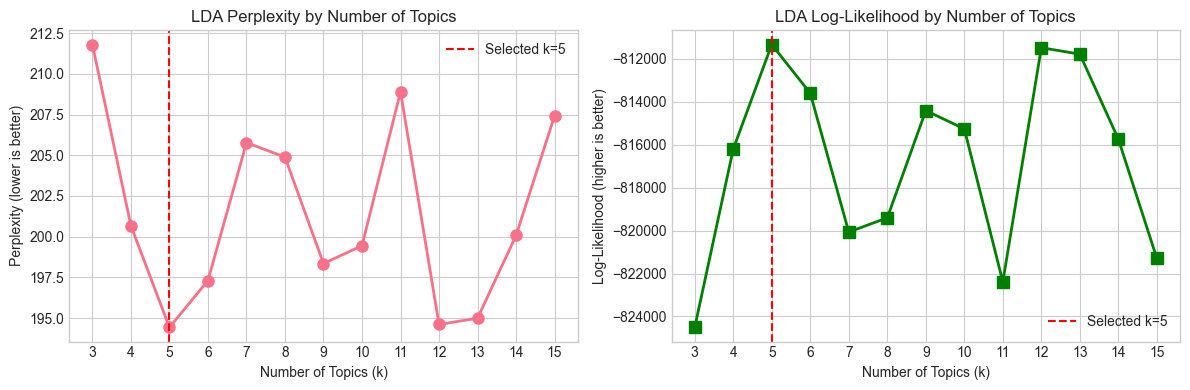

✓ Metrics plot saved


In [12]:
# Plot metrics
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax1 = axes[0]
ax1.plot(metrics_df['num_topics'], metrics_df['perplexity'], marker='o', linewidth=2, markersize=8)
ax1.axvline(x=optimal_k, color='red', linestyle='--', label=f'Selected k={optimal_k}')
ax1.set_xlabel('Number of Topics (k)')
ax1.set_ylabel('Perplexity (lower is better)')
ax1.set_title('LDA Perplexity by Number of Topics')
ax1.legend()
ax1.set_xticks(metrics_df['num_topics'])

ax2 = axes[1]
ax2.plot(metrics_df['num_topics'], metrics_df['log_likelihood'], marker='s', linewidth=2, markersize=8, color='green')
ax2.axvline(x=optimal_k, color='red', linestyle='--', label=f'Selected k={optimal_k}')
ax2.set_xlabel('Number of Topics (k)')
ax2.set_ylabel('Log-Likelihood (higher is better)')
ax2.set_title('LDA Log-Likelihood by Number of Topics')
ax2.legend()
ax2.set_xticks(metrics_df['num_topics'])

plt.tight_layout()

output_dir = Path('../outputs/03_topic_modeling')
output_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(output_dir / 'topic_selection_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Metrics plot saved")

---
## 5. Train Final LDA Model

In [13]:
print(f"Training final LDA model with k={optimal_k} topics...\n")

lda_model = LatentDirichletAllocation(
    n_components=optimal_k,
    random_state=RANDOM_STATE,
    max_iter=50,
    learning_method='online',
    batch_size=128,
    doc_topic_prior=None,
    topic_word_prior=None,
    n_jobs=-1
)

lda_model.fit(dtm)

print(f"✓ Model trained!")
print(f"  Final perplexity: {lda_model.perplexity(dtm):.1f}")
print(f"  Final log-likelihood: {lda_model.score(dtm):.1f}")

Training final LDA model with k=5 topics...

✓ Model trained!
  Final perplexity: 189.6
  Final log-likelihood: -807478.2


In [14]:
def display_topics(model, feature_names, n_words=10):
    topics = []
    for topic_idx, topic in enumerate(model.components_):
        top_word_indices = topic.argsort()[:-n_words-1:-1]
        top_words = [feature_names[i] for i in top_word_indices]
        topics.append({'topic_id': topic_idx, 'keywords': ', '.join(top_words)})
    return topics

print(f"\nDISCOVERED TOPICS (k={optimal_k})")
print("=" * 60)

topics = display_topics(lda_model, feature_names, n_words=10)
for t in topics:
    print(f"\nTopic {t['topic_id']}:")
    print(f"  {t['keywords']}")


DISCOVERED TOPICS (k=5)

Topic 0:
  policy, area, topic, chico, learn, learned, participation, state, community, choose

Topic 1:
  take, section, pol, 155, class, work, spring, would, took, state

Topic 2:
  describe, not, confidence, feel, help, increase, question, accurately, response, friend

Topic 3:
  event, experience, meeting, meaningful, describe, policy, mean, student, element, help

Topic 4:
  could, make, better, meeting, improved, more, group, time, would, like


---
## 6. Extract Topic Keywords and Assignments

In [15]:
# Extract top keywords per topic with weights
print("Extracting topic keywords...")

topic_keywords = []
for topic_id, topic in enumerate(lda_model.components_):
    topic_prob = topic / topic.sum()
    top_indices = topic_prob.argsort()[:-16:-1]
    for rank, idx in enumerate(top_indices, 1):
        topic_keywords.append({
            'topic_id': topic_id,
            'rank': rank,
            'keyword': feature_names[idx],
            'weight': topic_prob[idx]
        })

df_keywords = pd.DataFrame(topic_keywords)
print(f"  Extracted {len(df_keywords)} keyword entries ({optimal_k} topics × 15 words)")

Extracting topic keywords...
  Extracted 75 keyword entries (5 topics × 15 words)


In [16]:
# Get document-topic distributions
print("\nComputing document-topic distributions...")

doc_topic_dist = lda_model.transform(dtm)

doc_topics = []
for i in range(len(documents)):
    row = {
        'doc_id': i,
        'Semester': df.iloc[i]['Semester'],
        'Question_Category': df.iloc[i]['Question_Category']
    }
    
    for topic_id in range(optimal_k):
        row[f'topic_{topic_id}'] = doc_topic_dist[i, topic_id]
    
    row['dominant_topic'] = doc_topic_dist[i].argmax()
    row['dominant_topic_prob'] = doc_topic_dist[i].max()
    
    doc_topics.append(row)

df_assignments = pd.DataFrame(doc_topics)
print(f"✓ Computed topic distributions for {len(df_assignments):,} documents")


Computing document-topic distributions...
✓ Computed topic distributions for 3,585 documents


In [17]:
# Dominant topic distribution
print("\nDOMINANT TOPIC DISTRIBUTION")
print("=" * 50)

dominant_counts = df_assignments['dominant_topic'].value_counts().sort_index()
for topic_id, count in dominant_counts.items():
    pct = count / len(df_assignments) * 100
    top_words = df_keywords[df_keywords['topic_id'] == topic_id].head(3)['keyword'].tolist()
    print(f"  Topic {topic_id}: {count:5,} docs ({pct:5.1f}%) - {', '.join(top_words)}")


DOMINANT TOPIC DISTRIBUTION
  Topic 0:   684 docs ( 19.1%) - policy, area, topic
  Topic 1:   388 docs ( 10.8%) - take, section, pol
  Topic 2:   800 docs ( 22.3%) - describe, not, confidence
  Topic 3: 1,201 docs ( 33.5%) - event, experience, meeting
  Topic 4:   512 docs ( 14.3%) - could, make, better


---
## 7. Topic Prevalence by Semester

In [18]:
print("Analyzing topic trends by semester...\n")

topic_cols = [f'topic_{i}' for i in range(optimal_k)]
semester_topics = df_assignments.groupby('Semester')[topic_cols].mean()

print("TOPIC PREVALENCE BY SEMESTER (Mean Probability)")
print("=" * 60)
print(semester_topics.round(3).to_string())

Analyzing topic trends by semester...

TOPIC PREVALENCE BY SEMESTER (Mean Probability)
             topic_0  topic_1  topic_2  topic_3  topic_4
Semester                                                
Fall_2022      0.063    0.280    0.021    0.305    0.332
Fall_2023      0.944    0.013    0.008    0.014    0.021
Fall_2024      0.187    0.060    0.123    0.470    0.159
Fall_2025      0.189    0.057    0.462    0.234    0.059
Spring_2023    0.067    0.268    0.022    0.359    0.284
Spring_2024    0.749    0.020    0.032    0.122    0.076
Spring_2025    0.290    0.043    0.059    0.457    0.151


In [19]:
print("\nDOMINANT TOPIC COUNTS BY SEMESTER")
print("=" * 60)

semester_dominant = pd.crosstab(df_assignments['Semester'], df_assignments['dominant_topic'])
semester_dominant.columns = [f'Topic_{i}' for i in semester_dominant.columns]
print(semester_dominant.to_string())


DOMINANT TOPIC COUNTS BY SEMESTER
             Topic_0  Topic_1  Topic_2  Topic_3  Topic_4
Semester                                                
Fall_2022          6      217        0      249      254
Fall_2023        127        0        0        0        0
Fall_2024         34        2        3      188       17
Fall_2025        283        8      795      314        5
Spring_2023        5      160        0      229      177
Spring_2024      150        0        0       30       17
Spring_2025       79        1        2      191       42


In [20]:
# Create semester output DataFrame
df_semester_topics = semester_topics.reset_index()
df_semester_topics.columns = ['Semester'] + [f'topic_{i}_mean_prob' for i in range(optimal_k)]

dominant_pcts = semester_dominant.div(semester_dominant.sum(axis=1), axis=0) * 100
dominant_pcts = dominant_pcts.reset_index()
dominant_pcts.columns = ['Semester'] + [f'topic_{i}_pct_dominant' for i in range(optimal_k)]

df_semester_topics = df_semester_topics.merge(dominant_pcts, on='Semester')
print(f"\n✓ Created semester-topic summary: {len(df_semester_topics)} semesters")


✓ Created semester-topic summary: 7 semesters


---
## 8. Visualizations

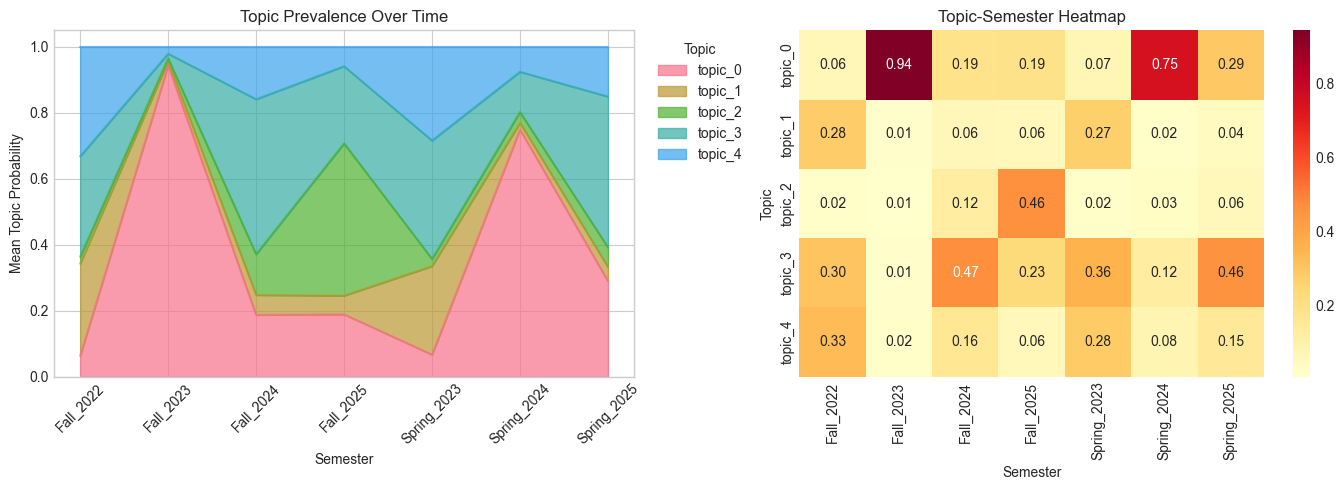

✓ Topic trends visualization saved


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
semester_order = sorted(df_assignments['Semester'].unique())
topic_data = semester_topics.reindex(semester_order)
topic_data.plot(kind='area', stacked=True, ax=ax1, alpha=0.7)
ax1.set_xlabel('Semester')
ax1.set_ylabel('Mean Topic Probability')
ax1.set_title('Topic Prevalence Over Time')
ax1.legend(title='Topic', bbox_to_anchor=(1.02, 1), loc='upper left')
ax1.tick_params(axis='x', rotation=45)

ax2 = axes[1]
sns.heatmap(topic_data.T, annot=True, fmt='.2f', cmap='YlOrRd', ax=ax2)
ax2.set_xlabel('Semester')
ax2.set_ylabel('Topic')
ax2.set_title('Topic-Semester Heatmap')

plt.tight_layout()
plt.savefig(output_dir / 'topic_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Topic trends visualization saved")

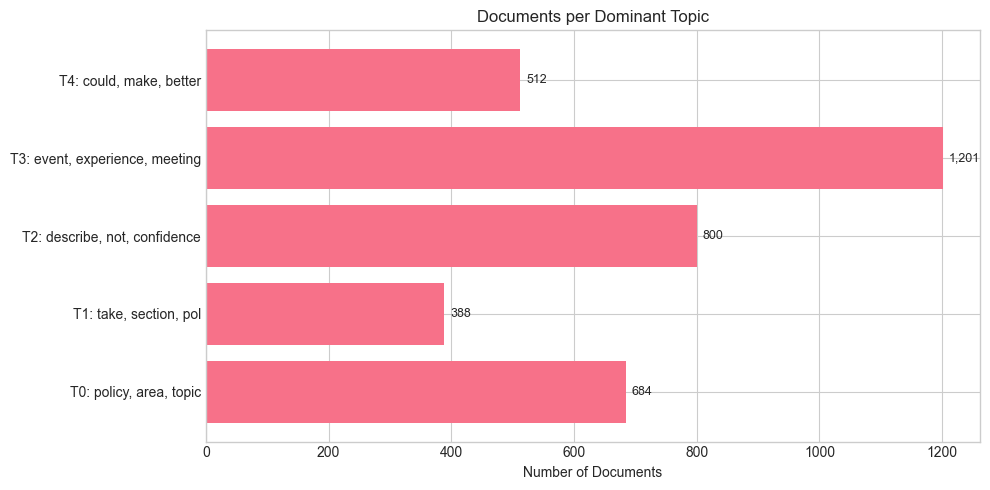

✓ Topic distribution chart saved


In [22]:
fig, ax = plt.subplots(figsize=(10, 5))

topic_labels = []
for i in range(optimal_k):
    top3 = df_keywords[df_keywords['topic_id'] == i].head(3)['keyword'].tolist()
    topic_labels.append(f"T{i}: {', '.join(top3)}")

counts = df_assignments['dominant_topic'].value_counts().sort_index()
bars = ax.barh(range(optimal_k), counts.values)
ax.set_yticks(range(optimal_k))
ax.set_yticklabels(topic_labels)
ax.set_xlabel('Number of Documents')
ax.set_title('Documents per Dominant Topic')

for bar, count in zip(bars, counts.values):
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2, f'{count:,}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(output_dir / 'topic_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Topic distribution chart saved")

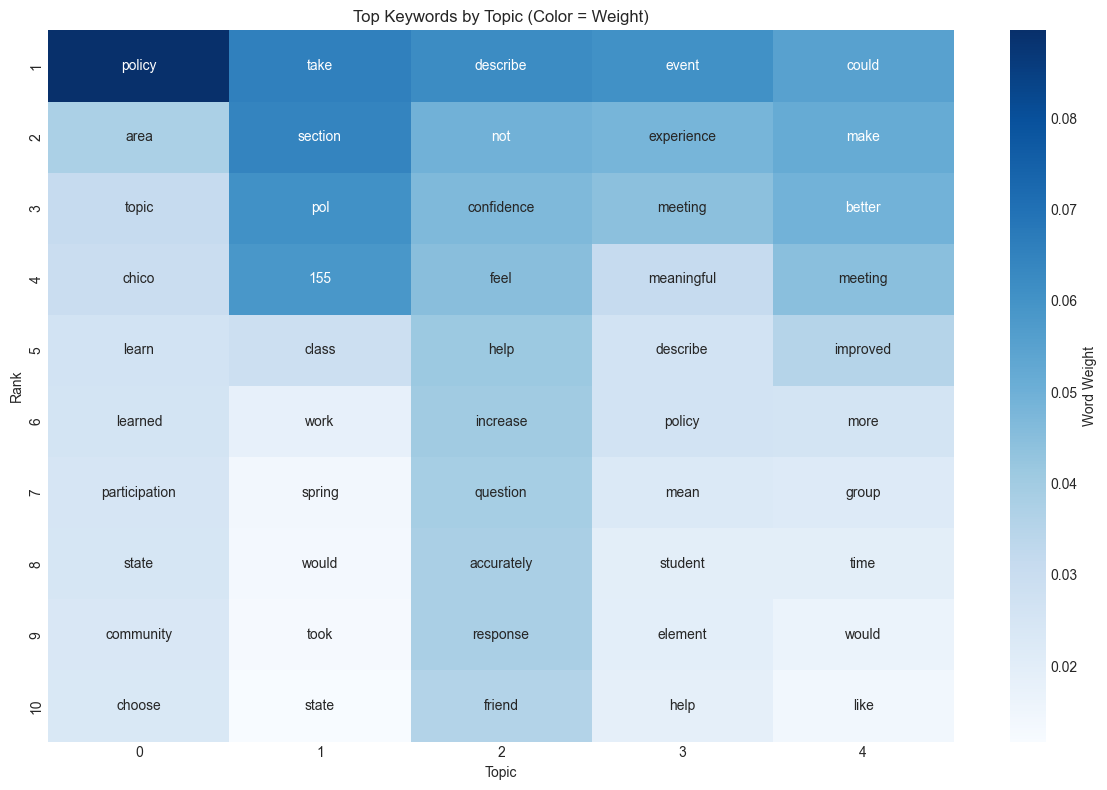

✓ Keywords heatmap saved


In [23]:
fig, ax = plt.subplots(figsize=(12, 8))

pivot_data = df_keywords[df_keywords['rank'] <= 10].pivot(index='rank', columns='topic_id', values='keyword')
weight_data = df_keywords[df_keywords['rank'] <= 10].pivot(index='rank', columns='topic_id', values='weight')
annot = pivot_data.values

sns.heatmap(weight_data, annot=annot, fmt='', cmap='Blues', ax=ax, cbar_kws={'label': 'Word Weight'})
ax.set_xlabel('Topic')
ax.set_ylabel('Rank')
ax.set_title('Top Keywords by Topic (Color = Weight)')

plt.tight_layout()
plt.savefig(output_dir / 'topic_keywords_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("✓ Keywords heatmap saved")

---
## 9. Save Outputs

In [24]:
print("Preparing output files...\n")

df_metrics = metrics_df[['num_topics', 'perplexity', 'log_likelihood']].copy()

print(f"Output files:")
print(f"  topic_keywords.csv: {len(df_keywords):,} rows")
print(f"  topic_assignments.csv: {len(df_assignments):,} rows")
print(f"  topic_by_semester.csv: {len(df_semester_topics):,} rows")
print(f"  topic_selection_metrics.csv: {len(df_metrics):,} rows")

Preparing output files...

Output files:
  topic_keywords.csv: 75 rows
  topic_assignments.csv: 3,585 rows
  topic_by_semester.csv: 7 rows
  topic_selection_metrics.csv: 13 rows


In [25]:
df_keywords.to_csv(output_dir / 'topic_keywords.csv', index=False)
df_assignments.to_csv(output_dir / 'topic_assignments.csv', index=False)
df_semester_topics.to_csv(output_dir / 'topic_by_semester.csv', index=False)
df_metrics.to_csv(output_dir / 'topic_selection_metrics.csv', index=False)

print("✓ Files saved locally")

✓ Files saved locally


In [26]:
print("\nUploading to Google Drive...\n")

if loader._write_ok:
    csv_files = [
        ('topic_keywords.csv', 'Topic keywords'),
        ('topic_assignments.csv', 'Document-topic assignments'),
        ('topic_by_semester.csv', 'Topic trends by semester'),
        ('topic_selection_metrics.csv', 'Model selection metrics')
    ]
    
    for filename, desc in csv_files:
        filepath = output_dir / filename
        existing_id = loader._get_existing_file_id(filename, PREPROCESSED_DATA_FOLDER_ID)
        
        if existing_id:
            file = loader.drive.CreateFile({'id': existing_id})
        else:
            file = loader.drive.CreateFile({
                'title': filename,
                'parents': [{'id': PREPROCESSED_DATA_FOLDER_ID}]
            })
        
        file.SetContentFile(str(filepath))
        file.Upload()
        print(f"✓ {desc}")
    
    print("\n✓ Upload complete!")
else:
    print("⚠ Write access unavailable - files saved locally only")


Uploading to Google Drive...

✓ Topic keywords
✓ Document-topic assignments
✓ Topic trends by semester
✓ Model selection metrics

✓ Upload complete!


In [27]:
import shutil
import gc
import time
import os

print("\n🗑️  Cleaning up local files...")

def delete_local_data():
    gc.collect()
    folder = '../outputs'
    
    if not os.path.exists(folder):
        print(f"    ⚠️  Folder not found (already clean): {folder}/")
        return
    
    max_retries = 3
    for attempt in range(max_retries):
        try:
            shutil.rmtree(folder)
            print(f"    ✅ Deleted local folder: {folder}/")
            break
        except PermissionError:
            if attempt < max_retries - 1:
                print(f"    ⚠️  Files locked, retrying in 2 seconds... (attempt {attempt + 1}/{max_retries})")
                time.sleep(2)
                gc.collect()
            else:
                print(f"    ❌ Could not delete folder - files are locked")
                return

    print("\n" + "=" * 65)
    print("  ✅ ALL DONE — topic modeling results saved to Drive.")
    print("=" * 65)

delete_local_data()


🗑️  Cleaning up local files...
    ⚠️  Files locked, retrying in 2 seconds... (attempt 1/3)
    ⚠️  Files locked, retrying in 2 seconds... (attempt 2/3)
    ❌ Could not delete folder - files are locked


---
## Summary

### Key Findings

This notebook applied LDA topic modeling to THM survey responses using scikit-learn:

1. **Document-Term Matrix**: Built using CountVectorizer with vocabulary filtering
2. **Model Selection**: Tested k=3 to 15 topics using perplexity and log-likelihood
3. **Topic Extraction**: Identified key themes with interpretable keyword lists
4. **Trend Analysis**: Tracked topic prevalence changes across semesters

### Outputs Generated

| File | Description |
|------|-------------|
| `topic_keywords.csv` | Top 15 keywords per topic with weights |
| `topic_assignments.csv` | Document-topic probability distributions |
| `topic_by_semester.csv` | Topic prevalence trends by semester |
| `topic_selection_metrics.csv` | Perplexity/log-likelihood for model selection |

### Next Steps

- **05_keyword_extraction**: Extract salient terms using TF-IDF and phrase extraction